**Extraire channels pour l'inference**

In [ ]:
import tifffile as tiff

nom_du_fichier = 'Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2_RGB_crop'

image = tiff.imread(f"./inference/inputs/{nom_du_fichier}.tif")

channel_selectionnés = 'RGB'
image_selected = image[:, :, [5, 3, 1]]
print(image_selected.shape)

tiff.imwrite(f"{nom_du_fichier}_{channel_selectionnés}.tif", image_selected)

**Visualisation de segmentation**

In [ ]:
import rasterio
import numpy as np

with rasterio.open("./inference/predictions/image_rgb_sans_nodata_seg.tif") as src:
    print(f"Dimensions: {src.shape}")  
    print(f"Nombre de bandes : {src.count}")
    segmentation = src.read(1)

# Statistiques de l’image
print(f"Min: {segmentation.min()}, Max: {segmentation.max()}, Moyenne: {segmentation.mean()}")

Dimensions: (1939, 734)
Nombre de bandes : 1
Min: 0, Max: 1, Moyenne: 0.04803523825450069


In [ ]:
# Normaliser entre 0 et 255
segmentation_normalized = (segmentation - segmentation.min()) / (segmentation.max() - segmentation.min()) * 255
segmentation_normalized = segmentation_normalized.astype(np.uint8)

# Sauvegarder l'image normalisée
with rasterio.open("segmentation_fixed.tif", "w", driver="GTiff",
                   height=segmentation.shape[0], width=segmentation.shape[1],
                   count=1, dtype=segmentation_normalized.dtype) as dst:
    dst.write(segmentation_normalized, 1)

c:\Users\Chris\anaconda3\envs\GLO70302_p\lib\site-packages\rasterio\__init__.py:378: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


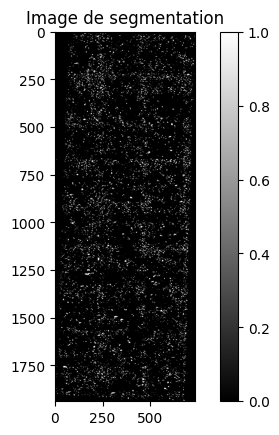

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(segmentation, cmap="gray")
plt.colorbar()
plt.title("Image de segmentation")
plt.show()

**Visualisation du fichier tif et des shapefiles**

C:\Users\Chris\AppData\Local\Temp\ipykernel_21380\3290794647.py:51: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
C:\Users\Chris\AppData\Local\Temp\ipykernel_21380\3290794647.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


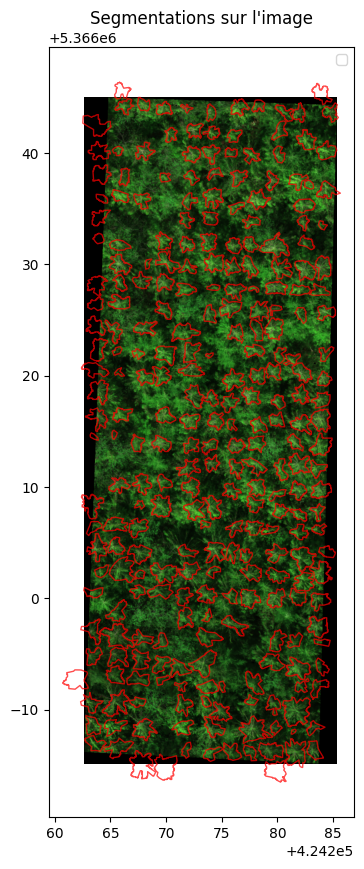

In [ ]:
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.plot import show
import numpy as np

# Charger l'image
nom_du_fichier = 'Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2_only_region_to_segment_0'
raster_path = f"./get_only_region_to_segment/{nom_du_fichier}.tif"

with rasterio.open(raster_path) as src:
    # Lire les bandes 
    red = src.read(6).astype(float)
    green = src.read(4).astype(float)
    blue = src.read(2).astype(float)

    # Lire la valeur NoData 
    nodata = src.nodata
    if nodata is None:
        nodata = -32767 

    # Masquer les valeurs NoData 
    mask = (red != nodata) & (green != nodata) & (blue != nodata)

    # Appliquer le masque (mettre 0 aux pixels invalides) (enlever artefact)
    red[~mask] = 0
    green[~mask] = 0
    blue[~mask] = 0

    # Empiler les bandes
    rgb = np.stack((red, green, blue), axis=-1)

    # Normalisation [0, 255]
    rgb_norm = np.clip((rgb - rgb.min()) / (rgb.max() - rgb.min()) * 255, 0, 255).astype(np.uint8)

    # Sauvegarder les infos de projection et transform pour affichage
    transform = src.transform
    crs = src.crs

# Charger les shapefiles
gdf_annotation = gpd.read_file("./get_only_region_to_segment/annotations_0.shp")

# Reprojeter si nécessaire
if gdf_annotation.crs != crs:
    gdf_annotation = gdf_annotation.to_crs(crs)

# Affichage
fig, ax = plt.subplots(figsize=(10, 10))
show(rgb_norm.transpose(2, 0, 1), transform=transform, ax=ax)
gdf_annotation.plot(ax=ax, edgecolor='red', linewidth=1, facecolor='none', alpha=0.7, label="Annotation")
plt.legend()
plt.title("Segmentations sur l'image")
plt.show()


**Downsampling l'image si nécessaire**

In [ ]:
import rasterio
from rasterio.enums import Resampling

input_path = "./preprocessing/raw_data/Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2.tif"
output_path = "./preprocessing/raw_data/Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2_20cm.tif"
scale_factor = 0.2  # Pour passer de 4 cm à 20 cm

with rasterio.open(input_path) as src:
    
    transform = src.transform
    width = int(src.width * scale_factor)
    height = int(src.height * scale_factor)
    
    # Recalcul du transform (résolution spatiale)
    new_transform = src.transform * src.transform.scale(
        (src.width / width),
        (src.height / height)
    )
    
    # Lire et downsampler l'image
    data = src.read(
        out_shape=(src.count, height, width),
        resampling=Resampling.average 
    )
    
    # Mettre à jour le profil
    profile = src.profile
    profile.update({
        "height": height,
        "width": width,
        "transform": new_transform
    })

    # Sauvegarder l'image downsampler
    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(data)

print("Image downsamplée enregistrée :", output_path)


Image downsamplée enregistrée : ./preprocessing/raw_data/Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2_20cm.tif


**Obtenir les images qui contiennent seulement les endroits qu'on doit segmenter**

In [ ]:
import os
import rasterio
from rasterio.mask import mask
import geopandas as gpd

import rasterio
from rasterio.enums import Resampling

image_name = "Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2"
tif_path = f"./preprocessing/raw_data/{image_name}.tif"
bbox_shapefile = f"./preprocessing/raw_data/example_rectangle.shp"
segmentation_shapefile = f"./preprocessing/raw_data/example_annotation.shp"

output_folder = "get_only_region_to_segment"
os.makedirs(output_folder, exist_ok=True)

#   Charger les shapefiles
bbox_gdf = gpd.read_file(bbox_shapefile)
segmentation_gdf = gpd.read_file(segmentation_shapefile)

with rasterio.open(tif_path) as src:
    if bbox_gdf.crs != src.crs:
        bbox_gdf = bbox_gdf.to_crs(src.crs)
    if segmentation_gdf.crs != src.crs:
        segmentation_gdf = segmentation_gdf.to_crs(src.crs)

    for i, bbox_geom in enumerate(bbox_gdf.geometry):
        try:
            # Masker l’image avec la bbox
            clipped_image, clipped_transform = mask(src, [bbox_geom], crop=True)
            
            # Fichier image de sortie
            out_tif = os.path.join(output_folder, f"{image_name}_only_region_to_segment_{i}.tif")

            # Sauvegarde TIFF
            out_meta = src.meta.copy()
            out_meta.update({
                "driver": "GTiff",
                "height": clipped_image.shape[1],
                "width": clipped_image.shape[2],
                "transform": clipped_transform
            })
            with rasterio.open(out_tif, "w", **out_meta) as dest:
                dest.write(clipped_image)
            print(f"Tuile image sauvegardée : {out_tif}")

            # Filtrer les polygones de segmentation qui intersectent cette bbox
            intersecting = segmentation_gdf[segmentation_gdf.geometry.intersects(bbox_geom)].copy()

            # Fichier shapefile de sortie
            out_shp = os.path.join(output_folder, f"annotations_{i}.shp")

            if not intersecting.empty:
                intersecting.to_file(out_shp, encoding='utf-8')
                print(f"Annotations sauvegardées : {out_shp}")
            else:
                print(f"Pas d'annotations dans bbox {i}")

        except Exception as e:
            print(f"Erreur pour bbox {i} : {e}")


Tuile image sauvegardée : get_only_region_to_segment\Cw_JR_East_2023_05_08_pan_IMG_0009_6_MS_alP1_cor2_only_region_to_segment_0.tif
Annotations sauvegardées : get_only_region_to_segment\annotations_0.shp
